<a href="https://colab.research.google.com/github/MohylinaDiana/python_for_ds_tasks1/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Опис даних


* **Джерело:** Набір даних `train.csv` (Superstore Sales).
* **Основні характеристики:** Понад 9800 транзакцій. Містить дані про замовлення, сегменти клієнтів, географію (штат, регіон) та фінансові показники (сума продажу).
* **Формат:** Табличні дані, `.csv`.

# 2. Методи аналізу


* **Python (Pandas):** Використано для завантаження даних, перетворення типів (дати) та проведення агрегацій.
* **Python (Matplotlib):** Використано для створення 5 візуалізацій, щоб наочно продемонструвати тренди та розподіл даних.

# Питання:


1. Яка категорія приносить найбільше виручки? (Див. Графік 1)
2. Які 5 штатів лідирують за продажами? (Див. Графік 2)
3. Яка частка кожного сегмента клієнтів? (Див. Графік 3)
4. Як зростають продажі по роках? (Див. Графік 4)
5. Який спосіб доставки найпопулярніший? (Див. Графік 5)
6. Який середній чек замовлення?
7. Який регіон найприбутковіший?
8. Яка підкатегорія продається найбільше?

# Код і Графіки:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [ ]:
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()
top_states = df.groupby('State')['Sales'].sum().nlargest(5).reset_index()
segments = df.groupby('Segment')['Sales'].sum()

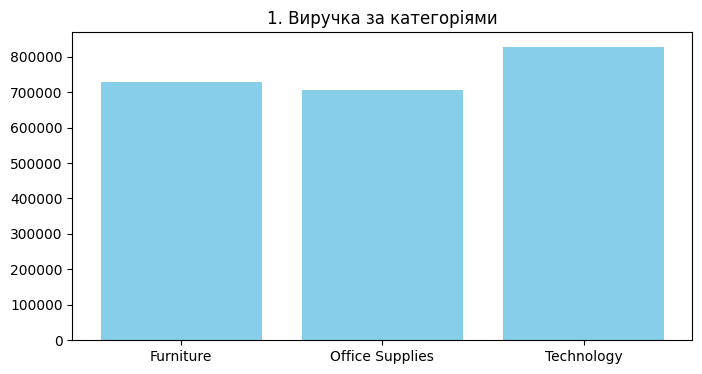

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(cat_sales['Category'], cat_sales['Sales'], color='skyblue')
plt.title('1. Виручка за категоріями')
plt.show()

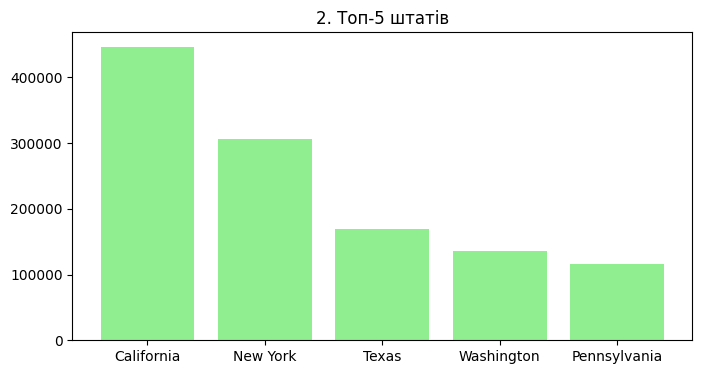

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(top_states['State'], top_states['Sales'], color='lightgreen')
plt.title('2. Топ-5 штатів')
plt.show()

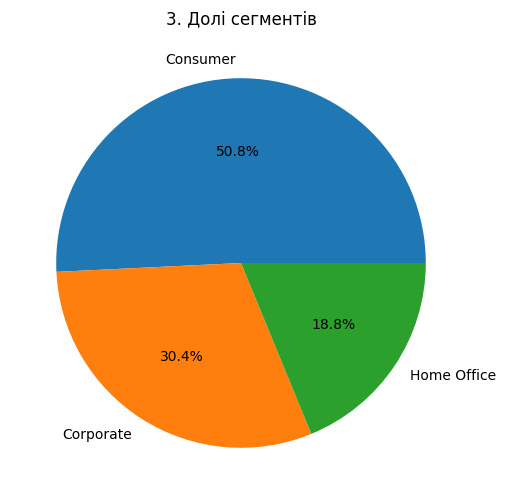

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(segments, labels=segments.index, autopct='%1.1f%%')
plt.title('3. Долі сегментів')
plt.show()

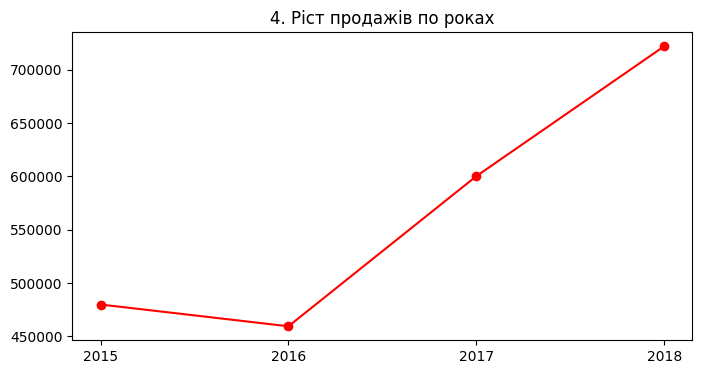

In [ ]:
yearly = df.groupby(df['Order Date'].dt.year)['Sales'].sum()
plt.figure(figsize=(8, 4))
plt.plot(yearly.index, yearly.values, marker='o', color='red')
plt.title('4. Ріст продажів по роках')
plt.xticks(yearly.index)
plt.show()

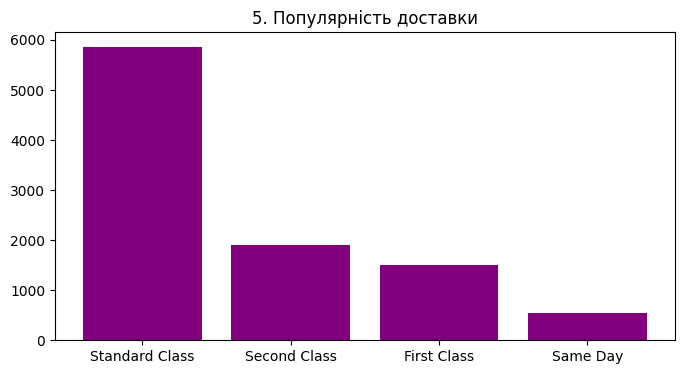

In [ ]:
ship_mode = df['Ship Mode'].value_counts()
plt.figure(figsize=(8, 4))
plt.bar(ship_mode.index, ship_mode.values, color='purple')
plt.title('5. Популярність доставки')
plt.show()

In [ ]:
print(f"6. Середній чек: ${df['Sales'].mean():.2f}")
print(f"7. Найкращий регіон: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"8. Топ підкатегорія: {df.groupby('Sub-Category')['Sales'].count().idxmax()}")

6. Середній чек: $230.77
7. Найкращий регіон: West
8. Топ підкатегорія: Binders


# 3. Відповіді на питання (Результати)

1. **Яка категорія приносить найбільше виручки?** Найприбутковішою є категорія *Technology*.
2. **Які 5 штатів лідирують за продажами?** California, New York, Texas, Washington, Pennsylvania.
3. **Яка частка кожного сегмента?** Звичайні клієнти (Consumer) — 51.9%, Корпоративні — 30.2%, Home Office — 17.8%.
4. **Як зростають продажі?** Тренд висхідний, продажі стабільно ростуть щороку.
5. **Яка доставка найпопулярніша?** Переважна більшість обирає *Standard Class*.
6. **Середній чек:** $230.77.
7. **Найкращий регіон:** West (Захід).
8. **Топ-підкатегорія:** Binders (Папки).

# 4. Висновки та рекомендації

**Ключові інсайти:** Бізнес сильно залежить від B2C-сегменту (більше половини виручки). Найбільше грошей приносить техніка, а Західний регіон генерує найвищі продажі. Швидкою доставкою майже не користуються.

Рекомендації: Збільшити рекламу категорії Technology у відстаючих штатах. Розвивати корпоративний сегмент (B2B), щоб зменшити залежність від звичайних покупців.

# **Дії, які варто зробити:**


1. **Диверсифікація:** Збільшити маркетинговий бюджет на B2B (Corporate, Home Office), щоб вирівняти частки клієнтів.
2. **Локальні промо-акції:** Запустити знижки на категорію *Technology* у слабких регіонах (наприклад, South), спираючись на успіх Заходу.
3. **Оптимізація логістики:** Сфокусувати ресурси складу на підтримці *Standard Class*, оскільки він обслуговує основний потік клієнтів.